# HOUSEHOLD VULNERABILITY ANALYTICS
**Identifikasi Rumah Tangga Rentan dan Analisis *Social Protection Gap***

**Konteks Kebijakan:**
Pengukuran kesejahteraan rumah tangga umumnya hanya berpusat pada dimensi moneter (Pengeluaran Per Kapita). Namun, dua rumah tangga dengan tingkat pengeluaran yang sama dapat mengalami tingkat deprivasi yang berbeda pada pemenuhan gizi dan standar perumahan dasar. 

**Tujuan Analisis:**
1. Mengembangkan *Vulnerability Index* multidimensi (Ekonomi, Pangan, Perumahan).
2. Memetakan *Social Protection Gap* untuk mengidentifikasi kelompok *Residual Vulnerability* (menerima bantuan namun tetap rentan) dan *Underserved* (rentan namun tidak menerima bantuan).
3. Membangun model Machine Learning untuk memprediksi profil rumah tangga berisiko tinggi.

**Sumber Data:**
SUSENAS September 2025 (Modul Kesehatan & Perumahan, Konsumsi Pengeluaran, dan Modul Individu untuk Kepala Rumah Tangga).

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style untuk visualisasi
sns.set_theme(style="whitegrid")

# STEP 1: LOAD DATASET
# Dataset ini merupakan hasil ETL (penggabungan) dari kp_blok43, mod_rt, dan mod_ind
print("Memuat dataset analitik...")
df = pd.read_csv('susenas_vulnerability_dataset.csv')

print(f"Total Observasi: {df.shape[0]:,} Rumah Tangga")
print(f"Total Fitur    : {df.shape[1]} Kolom")

Memuat dataset analitik...
Total Observasi: 76,928 Rumah Tangga
Total Fitur    : 19 Kolom


## STEP 2: MULTIDIMENSIONAL FEATURE ENGINEERING
Pendekatan *Rule-Based* digunakan untuk mendefinisikan tiga dimensi kerentanan:

1. **Economic Deprivation (`econ_vuln`)**: Rumah tangga berada pada 40% terbawah dari distribusi pengeluaran per kapita nasional.
2. **Food Deprivation (`food_vuln`)**: Konsumsi gizi di bawah standar minimum (Kalori < 2100 kkal atau Protein < 52 gram per kapita).
3. **Housing Deprivation (`housing_vuln`)**: Akses utilitas dasar yang buruk (contoh: penerangan utama bukan dari listrik PLN).

Rumah tangga diklasifikasikan memiliki **High Vulnerability** jika mengalami deprivasi pada minimal 2 dari 3 dimensi tersebut.

In [20]:
# A. Economic Deprivation (Bottom 40%)
threshold_40 = df['KAPITA'].quantile(0.40)
df['econ_vuln'] = (df['KAPITA'] <= threshold_40).astype(int)

# B. Food Deprivation (Kalori < 2100 atau Protein < 52)
df['food_vuln'] = ((df['CAL'] < 2100) | (df['PROT'] < 52)).astype(int)

# C. Housing Deprivation (M1504 kode 3: Listrik Non-PLN, 4: Bukan Listrik)
df['housing_vuln'] = df['M1504'].isin([3, 4]).astype(int)

# D. Aggregation: Vulnerability Score & Class
df['vulnerability_score'] = df['econ_vuln'] + df['food_vuln'] + df['housing_vuln']
df['high_vulnerability'] = (df['vulnerability_score'] >= 2).astype(int)

# Menyimpan data yang sudah ditambahkan target variabel untuk tahap ML
df.to_csv('susenas_ml_ready.csv', index=False)

## STEP 3: SOCIAL PROTECTION GAP MATRIX
Evaluasi *coverage* program perlindungan sosial (Bansos) terhadap status kerentanan rumah tangga. Matriks ini menggunakan nilai *weighting* (`FWT`) dari BPS agar persentase yang dihasilkan merepresentasikan estimasi populasi nasional yang sesungguhnya.

Fokus utama kita adalah mengidentifikasi dua kuadran:
*   **Potentially Underserved**: Rumah tangga rentan yang luput dari program bantuan.
*   **Residual Vulnerability**: Rumah tangga yang sudah diintervensi bantuan, namun masih terperangkap dalam kondisi rentan (indikasi ketidakcukupan nilai bantuan atau ketidaktepatan desain program).

In [21]:
# Kalkulasi Estimasi Populasi Nasional
total_pop = df['FWT'].sum()
high_vuln_pop = df[df['high_vulnerability'] == 1]['FWT'].sum()
bansos_pop = df[df['penerima_bansos'] == 1]['FWT'].sum()

print("=========================================================")
print("     HOUSEHOLD VULNERABILITY MONITOR (POPULATION ESTIMATE) ")
print("=========================================================")
print(f"Estimasi Populasi RT : {total_pop:,.0f} Rumah Tangga")
print(f"High Vulnerability   : {(high_vuln_pop / total_pop) * 100:.2f}%")
print(f"Penerima Bansos      : {(bansos_pop / total_pop) * 100:.2f}%\n")

# Membuat Crosstab Matrix berbobot
matrix = pd.crosstab(
    df['penerima_bansos'].map({0: 'No Assistance', 1: 'Assisted'}),
    df['high_vulnerability'].map({0: 'Low Vulnerability', 1: 'High Vulnerability'}),
    values=df['FWT'],
    aggfunc='sum',
    normalize='all'
) * 100

print("--- SOCIAL PROTECTION GAP MATRIX (%) ---")
display(matrix.round(2))

     HOUSEHOLD VULNERABILITY MONITOR (POPULATION ESTIMATE) 
Estimasi Populasi RT : 74,406,663 Rumah Tangga
High Vulnerability   : 32.56%
Penerima Bansos      : 35.40%

--- SOCIAL PROTECTION GAP MATRIX (%) ---


high_vulnerability,High Vulnerability,Low Vulnerability
penerima_bansos,,
Assisted,15.07,20.32
No Assistance,17.49,47.11


## STEP 4: DATA PREPARATION FOR MACHINE LEARNING
Kita akan menggunakan algoritma klasifikasi untuk memprediksi status kerentanan rumah tangga. Sebelum masuk ke pemodelan, dataset perlu disiapkan (handling missing values, mengubah tipe data kategorikal menjadi *dummy variables*, dan pembagian dataset).

**Variabel Prediktor (Features):**
*   `krt_jk`: Jenis Kelamin Kepala Rumah Tangga (KRT)
*   `krt_umur`: Umur KRT
*   `krt_pendidikan`: Pendidikan Tertinggi KRT
*   `krt_bekerja`: Status Bekerja KRT
*   `M1501`: Status Kepemilikan Bangunan
*   `penerima_bansos`: Status menerima bantuan (sebagai prediktor untuk melihat dampaknya)

**Variabel Target:**
*   `high_vulnerability` (1 = Ya, 0 = Tidak)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 1. Seleksi Fitur
features = ['krt_jk', 'krt_umur', 'krt_pendidikan', 'krt_bekerja', 'M1501', 'penerima_bansos']
target = 'high_vulnerability'

# Buat dataframe khusus ML, buang baris yang memiliki nilai kosong pada fitur utama
df_ml = df[features + [target]].dropna().copy()

# --- FIX: Konversi krt_bekerja dari 'A' menjadi 1 (Bekerja) dan 0 (Tidak Bekerja) ---
df_ml['krt_bekerja'] = df_ml['krt_bekerja'].apply(lambda x: 1 if str(x).strip() == 'A' else 0)

# 2. Encoding Variabel Kategorikal
# M1501 (Status Rumah) dan krt_pendidikan diubah menjadi format biner (One-Hot Encoding)
df_ml = pd.get_dummies(df_ml, columns=['M1501', 'krt_pendidikan'], drop_first=True)

# 3. Definisi X (Fitur) dan y (Target)
X = df_ml.drop(columns=[target])
y = df_ml[target]

# 4. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data latih (Train) : {X_train.shape[0]:,} baris")
print(f"Jumlah data uji (Test)    : {X_test.shape[0]:,} baris")

Jumlah data latih (Train) : 51,239 baris
Jumlah data uji (Test)    : 12,810 baris


## STEP 5: MODEL TRAINING & EVALUATION (RANDOM FOREST)
Kita menggunakan **Random Forest** karena kemampuannya menangani interaksi non-linear antar variabel (contoh: hubungan antara umur, pendidikan, dan kerentanan) dan kemampuannya menghasilkan indikator *Feature Importance* yang sangat berguna untuk merumuskan kebijakan.

Model akan dievaluasi menggunakan metrik standar klasifikasi (Precision, Recall, F1-Score, dan ROC-AUC).

In [23]:
# 1. Inisialisasi dan Pelatihan Model
# Menggunakan class_weight='balanced' karena ada kemungkinan ketidakseimbangan kelas target
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1)
print("Sedang melatih model Random Forest...")
rf_model.fit(X_train, y_train)
print("Pelatihan selesai!\n")

# 2. Prediksi pada Data Uji
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# 3. Evaluasi Model
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.3f}")

Sedang melatih model Random Forest...
Pelatihan selesai!

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.79      0.63      0.70      9095
           1       0.39      0.59      0.47      3715

    accuracy                           0.62     12810
   macro avg       0.59      0.61      0.59     12810
weighted avg       0.68      0.62      0.63     12810

ROC-AUC Score: 0.651


## STEP 6: EXPLAINABILITY (FEATURE IMPORTANCE)
Model prediktif tidak boleh menjadi *black-box* (kotak hitam). Kita harus mengekstrak bobot kepentingan variabel (*Feature Importance*) untuk memahami faktor demografis atau sosial-ekonomi mana yang paling kuat mendorong sebuah rumah tangga jatuh ke dalam status rentan.

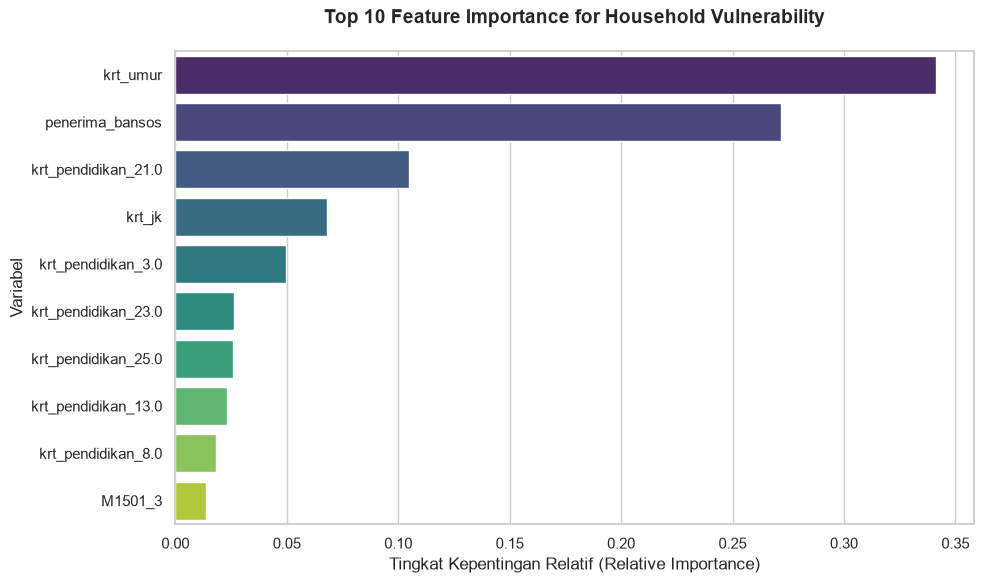

In [24]:
# Ekstrak feature importance
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualisasi Top 10 Features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importance for Household Vulnerability', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan Relatif (Relative Importance)')
plt.ylabel('Variabel')
plt.tight_layout()
plt.show()

## STEP 7: DEPLOYMENT PROTOTYPE (STREAMLIT)
Model dan metrik yang telah dievaluasi akan dideploy ke dalam dashboard interaktif. Skrip di bawah ini akan menghasilkan file `app.py` yang merupakan pondasi dasar aplikasi Streamlit untuk memonitor Household Vulnerability.

In [25]:
# Jalankan sel ini untuk men-generate file app.py secara otomatis di folder Anda
streamlit_code = """
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="Vulnerability Monitor", layout="wide")

st.title("Household Vulnerability & Social Protection Monitor")
st.markdown("Dashboard purwarupa untuk memantau kerentanan rumah tangga dan gap perlindungan sosial berdasarkan data SUSENAS.")

@st.cache_data
def load_data():
    # Membaca dataset yang sudah diproses di tahap sebelumnya
    df = pd.read_csv('susenas_ml_ready.csv')
    return df

df = load_data()

# Menghitung metrik populasi (berbasis FWT)
total_pop = df['FWT'].sum()
high_vuln_pop = df[df['high_vulnerability'] == 1]['FWT'].sum()
bansos_pop = df[df['penerima_bansos'] == 1]['FWT'].sum()

# Layout Kolom untuk Metrik Utama
col1, col2, col3 = st.columns(3)
col1.metric("Total Estimasi RT", f"{total_pop:,.0f}")
col2.metric("High Vulnerability", f"{(high_vuln_pop/total_pop)*100:.1f}%")
col3.metric("Coverage Bansos", f"{(bansos_pop/total_pop)*100:.1f}%")

st.divider()

# Layout Baris 2: Matrix dan Grafik
col_left, col_right = st.columns(2)

with col_left:
    st.subheader("Social Protection Gap Matrix")
    matrix = pd.crosstab(
        df['penerima_bansos'].map({0: 'No Assistance', 1: 'Assisted'}),
        df['high_vulnerability'].map({0: 'Low Vuln', 1: 'High Vuln'}),
        values=df['FWT'],
        aggfunc='sum',
        normalize='all'
    ) * 100
    st.dataframe(matrix.round(2), use_container_width=True)
    st.caption("Angka dalam persentase (%). Kuadran 'No Assistance - High Vuln' adalah prioritas intervensi utama.")

with col_right:
    st.subheader("Distribusi Usia KRT pada Kelompok Rentan")
    df_plot = df[df['high_vulnerability'] == 1]
    fig = px.histogram(df_plot, x='krt_umur', nbins=20, 
                       title="Sebaran Usia Kepala RT (High Vulnerability)",
                       labels={'krt_umur': 'Usia KRT'})
    st.plotly_chart(fig, use_container_width=True)
"""

with open("app.py", "w") as file:
    file.write(streamlit_code)

print("File 'app.py' berhasil dibuat! Buka terminal VSCode dan jalankan perintah:")
print("streamlit run app.py")

File 'app.py' berhasil dibuat! Buka terminal VSCode dan jalankan perintah:
streamlit run app.py
